# Credit Score Classification

# 02 Model Trainning

## Import Library

In [54]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid", {'axes.grid' : False})

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

import re
import time
import random
import tempfile
from tqdm.notebook import tqdm

import gc

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity

## Import Dataset

In [8]:
df_origin = pd.read_csv('cleaned data/clean_train.csv')
df = df_origin.copy()

## Check Dataset

In [9]:
df.shape

(100000, 28)

In [10]:
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.000,821000265.000,Scientist,19114.120,1824.843,3.000,...,Good,809.980,26.823,265.000,No,49.575,80.415,High_spent_Small_value_payments,312.494,Good
1,5635,3392,2,Aaron Maashoh,23.000,821000265.000,Scientist,19114.120,1824.843,3.000,...,Good,809.980,31.945,266.000,No,49.575,118.280,Low_spent_Large_value_payments,284.629,Good
2,5636,3392,3,Aaron Maashoh,23.000,821000265.000,Scientist,19114.120,1824.843,3.000,...,Good,809.980,28.609,267.000,No,49.575,81.700,Low_spent_Medium_value_payments,331.210,Good
3,5637,3392,4,Aaron Maashoh,23.000,821000265.000,Scientist,19114.120,1824.843,3.000,...,Good,809.980,31.378,268.000,No,49.575,199.458,Low_spent_Small_value_payments,223.451,Good
4,5638,3392,5,Aaron Maashoh,23.000,821000265.000,Scientist,19114.120,1824.843,3.000,...,Good,809.980,24.797,269.000,No,49.575,41.420,High_spent_Medium_value_payments,341.489,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,155625,37932,4,Nicks,25.000,78735990.000,Mechanic,39628.990,3359.416,4.000,...,Good,502.380,34.664,378.000,No,35.104,60.971,High_spent_Large_value_payments,479.866,Poor
99996,155626,37932,5,Nicks,25.000,78735990.000,Mechanic,39628.990,3359.416,4.000,...,Good,502.380,40.566,379.000,No,35.104,54.186,High_spent_Medium_value_payments,496.652,Poor
99997,155627,37932,6,Nicks,25.000,78735990.000,Mechanic,39628.990,3359.416,4.000,...,Good,502.380,41.256,380.000,No,35.104,24.028,High_spent_Large_value_payments,516.809,Poor
99998,155628,37932,7,Nicks,25.000,78735990.000,Mechanic,39628.990,3359.416,4.000,...,Good,502.380,33.638,381.000,No,35.104,251.673,Low_spent_Large_value_payments,319.165,Standard


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

## Drop Unnecessary Column

In [12]:
df.drop(columns=['ID', 'Customer_ID', 'Month', 'Name', 'SSN'], inplace=True)

In [13]:
df.shape

(100000, 23)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  float64
 5   Num_Credit_Card           100000 non-null  float64
 6   Interest_Rate             100000 non-null  float64
 7   Num_of_Loan               100000 non-null  float64
 8   Type_of_Loan              100000 non-null  object 
 9   Delay_from_due_date       100000 non-null  float64
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  ob

## Correlation (Covariance)

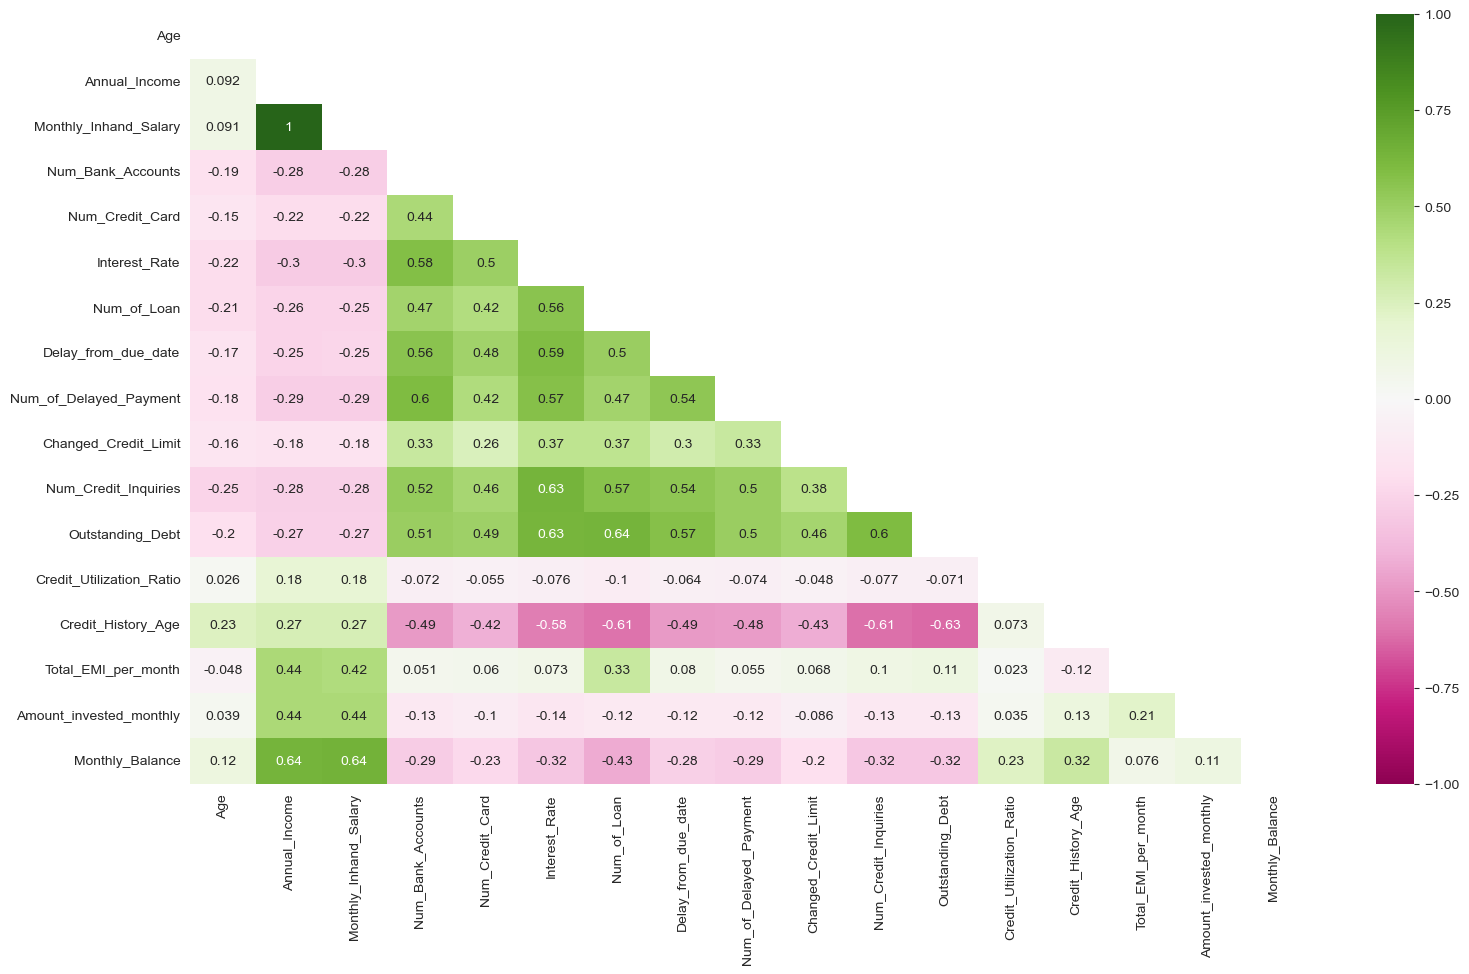

In [15]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(18, 10))
sns.heatmap(
    numeric_df.corr(), 
    mask=np.triu(np.ones_like(numeric_df.corr(), dtype=bool)), 
    annot=True, vmin=-1, vmax=1, cmap="PiYG"
);

## LabelEncoding for Output Column (Credit Score)

In [16]:
df["Credit_Score"]

0            Good
1            Good
2            Good
3            Good
4            Good
           ...   
99995        Poor
99996        Poor
99997        Poor
99998    Standard
99999        Poor
Name: Credit_Score, Length: 100000, dtype: object

In [17]:
Credit_Score_Encoder = LabelEncoder()

In [18]:
df["Credit_Score"] = Credit_Score_Encoder.fit_transform(df["Credit_Score"])

In [19]:
joblib.dump(Credit_Score_Encoder, 'encoder/Credit_Score_Encoder.pkl')

['encoder/Credit_Score_Encoder.pkl']

In [20]:
df["Credit_Score"]

0        0
1        0
2        0
3        0
4        0
        ..
99995    1
99996    1
99997    1
99998    2
99999    1
Name: Credit_Score, Length: 100000, dtype: int32

In [21]:
df["Credit_Score"].value_counts()

Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64

## Credit Score Correlation

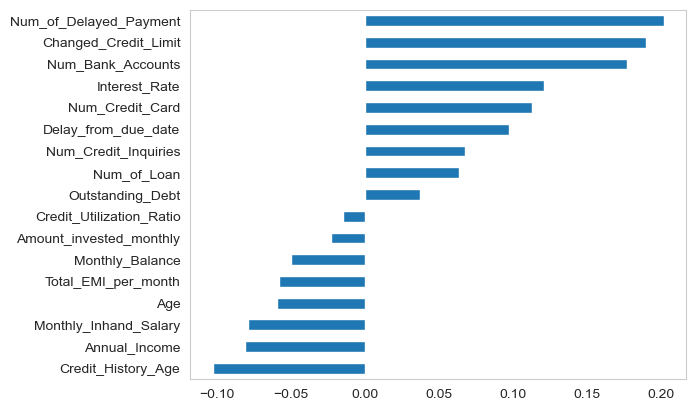

In [22]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_series = numerical_df.corr()['Credit_Score'][:-1].sort_values()
correlation_series.plot.barh();

## Encoding for Object Columns into Category Column

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  float64
 5   Num_Credit_Card           100000 non-null  float64
 6   Interest_Rate             100000 non-null  float64
 7   Num_of_Loan               100000 non-null  float64
 8   Type_of_Loan              100000 non-null  object 
 9   Delay_from_due_date       100000 non-null  float64
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  ob

In [24]:
df.select_dtypes(include=['object']).columns

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')

### Occupation

In [25]:
Occupation_Encoder = LabelEncoder()

In [26]:
df['Occupation'] = Occupation_Encoder.fit_transform(df['Occupation'])

In [27]:
joblib.dump(Occupation_Encoder, 'encoder/Occupation_Encoder.pkl')

['encoder/Occupation_Encoder.pkl']

### Type_of_Loan

In [28]:
Type_of_Loan_Encoder = LabelEncoder()

In [29]:
df['Type_of_Loan'] = Type_of_Loan_Encoder.fit_transform(df['Type_of_Loan'])

In [30]:
joblib.dump(Type_of_Loan_Encoder, 'encoder/Type_of_Loan_Encoder.pkl')

['encoder/Type_of_Loan_Encoder.pkl']

### Credit Mix

In [31]:
Credit_Mix_Encoder = OrdinalEncoder()

In [32]:
df['Credit_Mix'] = Credit_Mix_Encoder.fit_transform(df[['Credit_Mix']])

In [33]:
joblib.dump(Credit_Mix_Encoder, 'encoder/Credit_Mix_Encoder.pkl')

['encoder/Credit_Mix_Encoder.pkl']

### Payment_of_Min_Amount

In [34]:
Payment_of_Min_Amount_Encoder = LabelEncoder()

In [35]:
df['Payment_of_Min_Amount'] = Payment_of_Min_Amount_Encoder.fit_transform(df['Payment_of_Min_Amount'])

In [36]:
joblib.dump(Payment_of_Min_Amount_Encoder, 'encoder/Payment_of_Min_Amount_Encoder.pkl')

['encoder/Payment_of_Min_Amount_Encoder.pkl']

### Payment_Behaviour

In [37]:
Payment_Behaviour_Categories = ['Low_spent_Small_value_payments',
                                'Low_spent_Medium_value_payments',
                                'Low_spent_Large_value_payments',
                                'High_spent_Small_value_payments',
                                'High_spent_Medium_value_payments',
                                'High_spent_Large_value_payments']

Payment_Behaviour_Encoder = OrdinalEncoder(categories=[Payment_Behaviour_Categories])

In [38]:
df['Payment_Behaviour'] = Payment_Behaviour_Encoder.fit_transform(df[['Payment_Behaviour']])

In [39]:
joblib.dump(Payment_Behaviour_Encoder, 'encoder/Payment_Behaviour_Encoder.pkl')

['encoder/Payment_Behaviour_Encoder.pkl']

In [40]:
df

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.000,12,19114.120,1824.843,3.000,4.000,3.000,4.000,128,3.000,...,1.000,809.980,26.823,265.000,1,49.575,80.415,3.000,312.494,0
1,23.000,12,19114.120,1824.843,3.000,4.000,3.000,4.000,128,3.000,...,1.000,809.980,31.945,266.000,1,49.575,118.280,2.000,284.629,0
2,23.000,12,19114.120,1824.843,3.000,4.000,3.000,4.000,128,3.000,...,1.000,809.980,28.609,267.000,1,49.575,81.700,1.000,331.210,0
3,23.000,12,19114.120,1824.843,3.000,4.000,3.000,4.000,128,5.000,...,1.000,809.980,31.378,268.000,1,49.575,199.458,0.000,223.451,0
4,23.000,12,19114.120,1824.843,3.000,4.000,3.000,4.000,128,6.000,...,1.000,809.980,24.797,269.000,1,49.575,41.420,4.000,341.489,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25.000,9,39628.990,3359.416,4.000,6.000,7.000,2.000,683,23.000,...,1.000,502.380,34.664,378.000,1,35.104,60.971,5.000,479.866,1
99996,25.000,9,39628.990,3359.416,4.000,6.000,7.000,2.000,683,18.000,...,1.000,502.380,40.566,379.000,1,35.104,54.186,4.000,496.652,1
99997,25.000,9,39628.990,3359.416,4.000,6.000,7.000,2.000,683,27.000,...,1.000,502.380,41.256,380.000,1,35.104,24.028,5.000,516.809,1
99998,25.000,9,39628.990,3359.416,4.000,6.000,7.000,2.000,683,20.000,...,1.000,502.380,33.638,381.000,1,35.104,251.673,2.000,319.165,2


In [41]:
print(df.iloc[0])

Age                           23.000
Occupation                    12.000
Annual_Income              19114.120
Monthly_Inhand_Salary       1824.843
Num_Bank_Accounts              3.000
Num_Credit_Card                4.000
Interest_Rate                  3.000
Num_of_Loan                    4.000
Type_of_Loan                 128.000
Delay_from_due_date            3.000
Num_of_Delayed_Payment         7.000
Changed_Credit_Limit          11.270
Num_Credit_Inquiries           4.000
Credit_Mix                     1.000
Outstanding_Debt             809.980
Credit_Utilization_Ratio      26.823
Credit_History_Age           265.000
Payment_of_Min_Amount          1.000
Total_EMI_per_month           49.575
Amount_invested_monthly       80.415
Payment_Behaviour              3.000
Monthly_Balance              312.494
Credit_Score                   0.000
Name: 0, dtype: float64


## Saparate Property (Data and Label)

In [42]:
X = df.drop("Credit_Score", axis=1)
y = df.Credit_Score

## Normalize Y

In [43]:
y.value_counts(normalize=True)

Credit_Score
2   0.532
1   0.290
0   0.178
Name: proportion, dtype: float64

In [44]:
y.value_counts()

Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64

## Train Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, shuffle=True, random_state=42)

In [46]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (85000, 22) (85000,)
Testing set shape: (15000, 22) (15000,)


## Normalize X_Train X_Test

In [47]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ANN Model

In [42]:
model = Sequential([
    Dense(512, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'), 
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    Dense(3, activation='softmax')
])

model.compile(optimizer = Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=70,
                               restore_best_weights=True)

model.fit(x=X_train,
          y=y_train,
          validation_data=(X_test, y_test),
          validation_split=0.1,
          batch_size=512,
          epochs=900,
          verbose=1,
          callbacks=[early_stopping])

Epoch 1/900
167/167 [==============================] - 5s 16ms/step - loss: 0.9457 - accuracy: 0.6053 - val_loss: 0.8113 - val_accuracy: 0.6329
Epoch 2/900
167/167 [==============================] - 3s 16ms/step - loss: 0.7535 - accuracy: 0.6660 - val_loss: 0.7205 - val_accuracy: 0.6752
Epoch 3/900
167/167 [==============================] - 3s 16ms/step - loss: 0.7166 - accuracy: 0.6807 - val_loss: 0.6812 - val_accuracy: 0.6954
Epoch 4/900
167/167 [==============================] - 3s 15ms/step - loss: 0.7016 - accuracy: 0.6864 - val_loss: 0.6724 - val_accuracy: 0.6971
Epoch 5/900
167/167 [==============================] - 2s 15ms/step - loss: 0.6972 - accuracy: 0.6876 - val_loss: 0.6702 - val_accuracy: 0.6996
Epoch 6/900
167/167 [==============================] - 3s 15ms/step - loss: 0.6906 - accuracy: 0.6923 - val_loss: 0.6675 - val_accuracy: 0.7034
Epoch 7/900
167/167 [==============================] - 2s 15ms/step - loss: 0.6837 - accuracy: 0.6963 - val_loss: 0.6705 - val_accuracy:

In [43]:
model.evaluate(X_train, y_train)

2657/2657 [==============================] - 3s 1ms/step - loss: 0.3888 - accuracy: 0.8396


[0.3887811005115509, 0.8395529389381409]

## Model Evaluation

In [44]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred_probabilities = model.predict(X_train)
    y_train_pred = y_train_pred_probabilities.argmax(axis=1)
    
    y_pred_probabilities = model.predict(X_test)
    y_pred = y_pred_probabilities.argmax(axis=1)

    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_pred)

    metrics_df = pd.DataFrame({
        'Metric': ['True Positives', 'False Positives', 'False Negatives', 'True Negatives'],
        'Train Set': [cm_train[1, 1], cm_train[0, 1], cm_train[1, 0], cm_train[0, 0]],
        'Test Set': [cm_test[1, 1], cm_test[0, 1], cm_test[1, 0], cm_test[0, 0]]
    })

    print("Metrics Summary:")
    print(metrics_df)

    print("\nTest Set Confusion Matrix:")
    print(cm_test)
    print("\nTest Set Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nTrain Set Confusion Matrix:")
    print(cm_train)
    print("\nTrain Set Classification Report:")
    print(classification_report(y_train, y_train_pred))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
                yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.title('Test Set Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

    plt.subplot(1, 2, 2)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
                yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.title('Train Set Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

    plt.tight_layout()
    plt.show()

469/469 [==============================] - 1s 1ms/step
Metrics Summary:
            Metric  Train Set  Test Set
0   True Positives      22206      3707
1  False Positives          8        10
2  False Negatives         34        28
3   True Negatives      13092      2186

Test Set Confusion Matrix:
[[2186   10  478]
 [  28 3707  615]
 [ 757 1059 6160]]

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.77      2674
           1       0.78      0.85      0.81      4350
           2       0.85      0.77      0.81      7976

    accuracy                           0.80     15000
   macro avg       0.79      0.81      0.80     15000
weighted avg       0.81      0.80      0.80     15000


Train Set Confusion Matrix:
[[13092     8  2054]
 [   34 22206  2408]
 [ 3559  5575 36064]]

Train Set Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     1

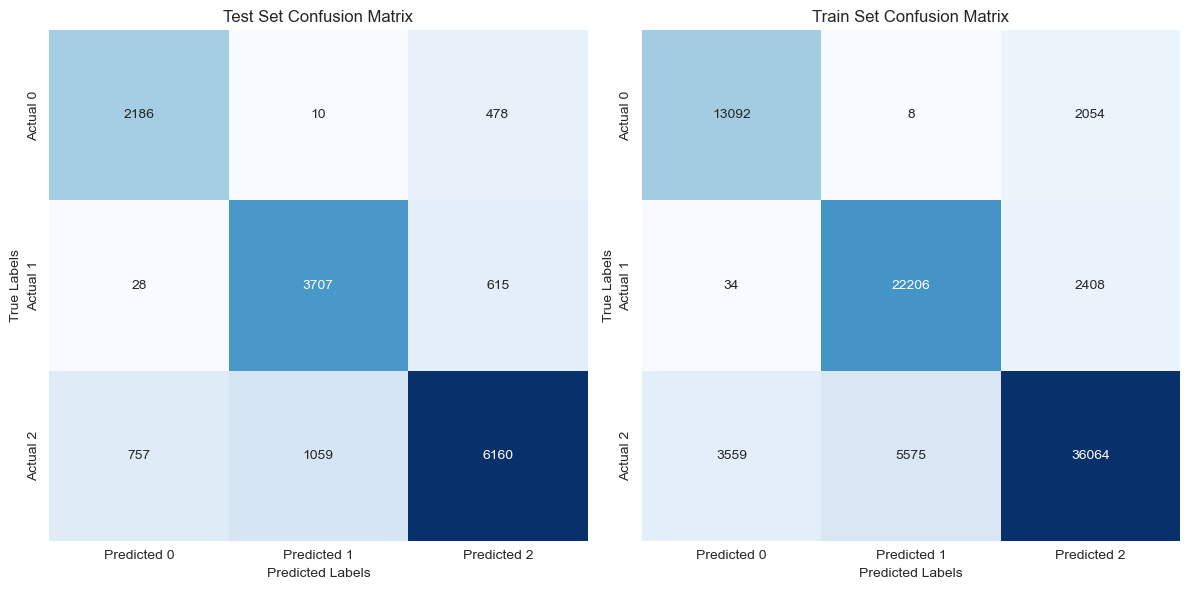

In [45]:
eval_metric(model, X_train, y_train, X_test, y_test)

## Save Model

In [46]:
model.save('model/Credit_Score_Classification_Model.keras')

In [61]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def eval_metric(model, X_train, y_train, X_test, y_test):
    # Predict probabilities
    y_train_pred_probabilities = model.predict(X_train)
    y_train_pred = y_train_pred_probabilities.argmax(axis=1)

    y_pred_probabilities = model.predict(X_test)
    y_pred = y_pred_probabilities.argmax(axis=1)

    # Confusion Matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_pred)

    # Metrics Summary DataFrame
    metrics_df = pd.DataFrame({
        'Metric': ['True Positives', 'False Positives', 'False Negatives', 'True Negatives'],
        'Train Set': [cm_train[1, 1], cm_train[0, 1], cm_train[1, 0], cm_train[0, 0]],
        'Test Set': [cm_test[1, 1], cm_test[0, 1], cm_test[1, 0], cm_test[0, 0]]
    })

    print("Metrics Summary:")
    print(metrics_df)

    # Cosine Similarity Evaluation
    # Reshape predicted probabilities to 2D if needed
    # Ensure y_train and y_test are 1D arrays
    y_train_array = np.array(y_train)  # 1D array
    y_test_array = np.array(y_test)     # 1D array

    # Convert predicted probabilities to correct shape
    y_train_pred_probabilities_reshaped = y_train_pred_probabilities
    y_test_pred_probabilities_reshaped = y_pred_probabilities

    # Ensure both arrays are 2D for cosine similarity calculation
    if len(y_train_pred_probabilities_reshaped.shape) == 1:
        y_train_pred_probabilities_reshaped = y_train_pred_probabilities_reshaped.reshape(-1, 1)
    if len(y_test_pred_probabilities_reshaped.shape) == 1:
        y_test_pred_probabilities_reshaped = y_test_pred_probabilities_reshaped.reshape(-1, 1)

    # Calculate cosine similarity
    cosine_sim_train = cosine_similarity(y_train_pred_probabilities_reshaped.T, y_train_array.reshape(1, -1))
    cosine_sim_test = cosine_similarity(y_test_pred_probabilities_reshaped.T, y_test_array.reshape(1, -1))

    print(f"\nCosine Similarity (Train Set): {np.mean(cosine_sim_train):.4f}")
    print(f"Cosine Similarity (Test Set): {np.mean(cosine_sim_test):.4f}")

    # Confusion Matrices and Classification Reports
    print("\nTest Set Confusion Matrix:")
    print(cm_test)
    print("\nTest Set Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nTrain Set Confusion Matrix:")
    print(cm_train)
    print("\nTrain Set Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
                yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.title('Test Set Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

    plt.subplot(1, 2, 2)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
                yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.title('Train Set Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

    plt.tight_layout()
    plt.show()


469/469 [==============================] - 1s 1ms/step
Metrics Summary:
            Metric  Train Set  Test Set
0   True Positives      22206      3707
1  False Positives          8        10
2  False Negatives         34        28
3   True Negatives      13092      2186

Cosine Similarity (Train Set): 0.5406
Cosine Similarity (Test Set): 0.5475

Test Set Confusion Matrix:
[[2186   10  478]
 [  28 3707  615]
 [ 757 1059 6160]]

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.82      0.77      2674
           1       0.78      0.85      0.81      4350
           2       0.85      0.77      0.81      7976

    accuracy                           0.80     15000
   macro avg       0.79      0.81      0.80     15000
weighted avg       0.81      0.80      0.80     15000


Train Set Confusion Matrix:
[[13092     8  2054]
 [   34 22206  2408]
 [ 3559  5575 36064]]

Train Set Classification Report:
              precision    r

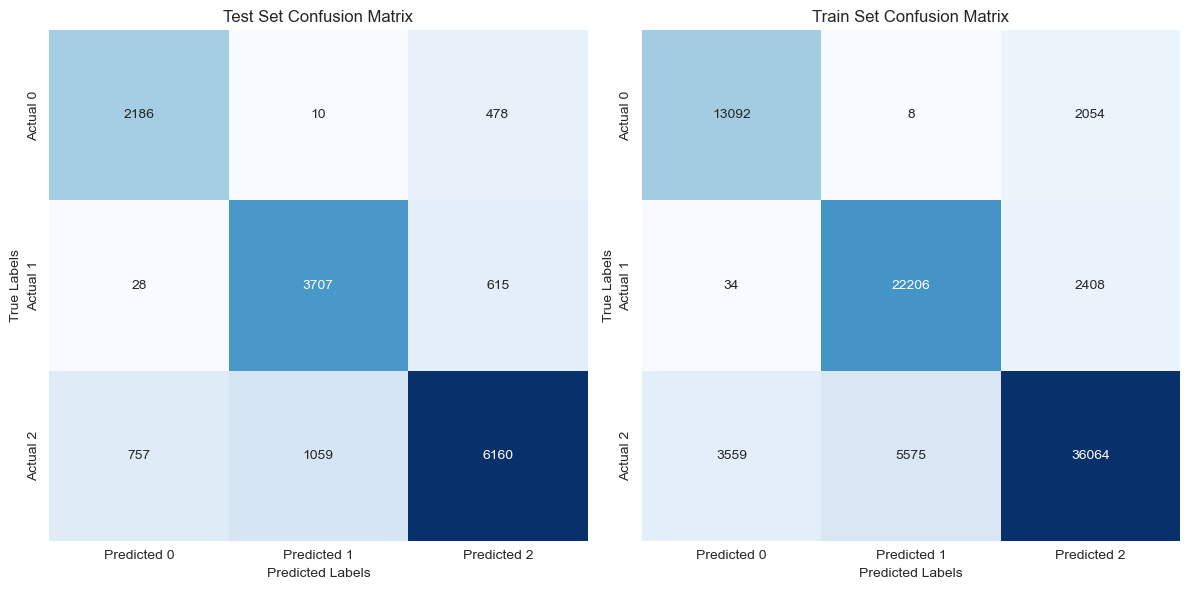

In [62]:
eval_metric(model, X_train, y_train, X_test, y_test)